In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
from glob import glob

In [51]:
import pandas as pd

# Dataset paths
datasets = {
    "fund_master": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/01_fund_master.csv",

    "nav_history": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/02_nav_history.csv",

    "aum_by_fund_house": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/03_aum_by_fund_house.csv",

    "monthly_sip_inflows": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/04_monthly_sip_inflows.csv",

    "category_inflows": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/05_category_inflows.csv",

    "industry_folio_count": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/06_industry_folio_count.csv",

    "scheme_performance": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/07_scheme_performance.csv",

    "investor_transactions": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/08_investor_transactions.csv",

    "portfolio_holdings": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/09_portfolio_holdings.csv",

    "benchmark_indices": "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/10_benchmark_indices.csv"
}

# Dictionary to store loaded dataframes
loaded_data = {}

# Load and inspect all datasets
for name, path in datasets.items():

    print("\n" + "="*100)
    print(f"DATASET: {name.upper()}")
    print("="*100)

    try:
        # Load dataset
        df = pd.read_csv(path)

        # Store dataframe
        loaded_data[name] = df

        # Shape
        print("\n1. Shape:")
        print(df.shape)

        # Data types
        print("\n2. Data Types:")
        print(df.dtypes)

        # First 5 rows
        print("\n3. First 5 Rows:")
        print(df.head())

        # Missing values
        print("\n4. Missing Values:")
        print(df.isnull().sum())

        # Duplicate rows
        print("\n5. Duplicate Rows:")
        print(df.duplicated().sum())

    except Exception as e:
        print(f"\nError loading {name}: {e}")

print("\n" + "="*100)
print("ALL DATASETS LOADED SUCCESSFULLY")
print("="*100)


DATASET: FUND_MASTER

1. Shape:
(40, 15)

2. Data Types:
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object

3. First 5 Rows:
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Pla

All 10 datasets loaded successfully.
Some datasets contain missing values.
Duplicate rows detected in few datasets.
Date columns require datatype conversion.
Some numerical columns are stored as object datatype.
Data cleaning and preprocessing will be required before analysis.

In [52]:
import requests
import pandas as pd

# API URL
url = "https://api.mfapi.in/mf/125497"

# Request API
response = requests.get(url)

# Convert JSON
data = response.json()

# Print Scheme Name
print("Scheme Name:", data['meta']['scheme_name'])

# Convert NAV data into DataFrame
nav_df = pd.DataFrame(data['data'])

# Display first rows
print(nav_df.head())

# Save CSV
nav_df.to_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/hdfc_top100_live_nav.csv",
    index=False
)

print("Live NAV CSV saved successfully")

Scheme Name: SBI Small Cap Fund - Direct Plan - Growth
         date        nav
0  02-06-2026  193.12950
1  01-06-2026  192.31950
2  31-05-2026  193.68360
3  29-05-2026  193.68480
4  27-05-2026  195.05010
Live NAV CSV saved successfully


In [53]:
import requests
import pandas as pd
import time

schemes = {
    "SBI_Bluechip": 119551,
    "ICICI_Bluechip": 120503,
    "Nippon_Large_Cap": 118632,
    "Axis_Bluechip": 119092,
    "Kotak_Bluechip": 120841
}

all_nav_data = []

for scheme_name, scheme_code in schemes.items():

    print(f"Fetching {scheme_name}")

    url = f"https://api.mfapi.in/mf/{scheme_code}"

    response = requests.get(url)

    data = response.json()

    temp_df = pd.DataFrame(data['data'])

    temp_df['scheme_name'] = scheme_name
    temp_df['scheme_code'] = scheme_code

    all_nav_data.append(temp_df)

    time.sleep(1)

# Combine all datasets
final_nav_df = pd.concat(all_nav_data, ignore_index=True)

# Save CSV
final_nav_df.to_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/key_schemes_nav.csv",
    index=False
)

print(final_nav_df.head())
print("All NAV data saved successfully")

Fetching SBI_Bluechip
Fetching ICICI_Bluechip
Fetching Nippon_Large_Cap
Fetching Axis_Bluechip
Fetching Kotak_Bluechip
         date        nav   scheme_name  scheme_code
0  02-06-2026  104.76630  SBI_Bluechip       119551
1  01-06-2026  104.70250  SBI_Bluechip       119551
2  29-05-2026  104.65700  SBI_Bluechip       119551
3  27-05-2026  104.58330  SBI_Bluechip       119551
4  26-05-2026  104.52690  SBI_Bluechip       119551
All NAV data saved successfully


In [54]:
fund_master = loaded_data['fund_master']

print("Unique Fund Houses")
print(fund_master['fund_house'].unique())

print("\nCategories")
print(fund_master['category'].unique())

print("\nSub Categories")
print(fund_master['sub_category'].unique())

print("\nRisk Grades")
print(fund_master['risk_category'].unique())

Unique Fund Houses
['SBI Mutual Fund' 'HDFC Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Kotak Mahindra MF' 'Axis Mutual Fund'
 'Aditya Birla Sun Life MF' 'UTI Mutual Fund' 'Mirae Asset MF'
 'DSP Mutual Fund']

Categories
['Equity' 'Debt']

Sub Categories
['Large Cap' 'Small Cap' 'Gilt' 'Mid Cap' 'Short Duration' 'Value'
 'Liquid' 'Index/ETF' 'Flexi Cap' 'Index' 'Large & Mid Cap' 'ELSS']

Risk Grades
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [55]:
fund_master.columns


Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [56]:
fund_master = loaded_data['fund_master']
nav_history = loaded_data['nav_history']

# Convert to string
master_codes = set(fund_master['amfi_code'].astype(str))
nav_codes = set(nav_history['amfi_code'].astype(str))

# Find missing codes
missing_codes = master_codes - nav_codes

print("Total Fund Master Codes:", len(master_codes))
print("Total NAV History Codes:", len(nav_codes))
print("Missing Codes:", len(missing_codes))

print("\nSample Missing Codes:")
print(list(missing_codes)[:10])

Total Fund Master Codes: 40
Total NAV History Codes: 40
Missing Codes: 0

Sample Missing Codes:
[]


All datasets loaded successfully.
Missing values found in multiple datasets.
Duplicate rows identified in some datasets.
Date columns need conversion to datetime datatype.
Some numerical columns stored as object datatype.
Few AMFI codes are missing in NAV history.
Data preprocessing and cleaning required before analysis.

# Data Cleaning and preprocessing

In [57]:
# Check null values
print(nav_history.isnull().sum())

# Check duplicates
print(nav_history.duplicated().sum())

# Convert date column
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Sort values
nav_history = nav_history.sort_values(by='date')

print(nav_history.head())

amfi_code         0
date              0
nav               0
Unnamed: 3    46000
Unnamed: 4    46000
Unnamed: 5    46000
Unnamed: 6    46000
dtype: int64
0
       amfi_code       date       nav  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0         119551 2022-01-03   54.3856         NaN         NaN         NaN   
5750      100016 2022-01-03  520.4608         NaN         NaN         NaN   
31050     119095 2022-01-03   52.5238         NaN         NaN         NaN   
44850     149324 2022-01-03   81.6814         NaN         NaN         NaN   
32200     101206 2022-01-03  305.0996         NaN         NaN         NaN   

       Unnamed: 6  
0             NaN  
5750          NaN  
31050         NaN  
44850         NaN  
32200         NaN  


# NAV Trend Analysis (2022–2026)

In [58]:
fig = px.line(
    final_nav_df,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend of Mutual Fund Schemes'
)

# Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run"
)

# Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Correction"
)

fig.show()

In [59]:
fig.write_image(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/reports/charts/nav_trend.png"
)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


### Insight
Most large-cap mutual funds showed strong NAV growth during the 2023 bull market phase.

In [60]:
# Create dataframe variable

aum_by_fund_house = loaded_data['aum_by_fund_house']

# Check columns
print(aum_by_fund_house.columns)

print(aum_by_fund_house.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0  2022-03-31      SBI Mutual Fund            6.05     605000          186   
1  2022-03-31  ICICI Prudential MF            4.65     465000          216   
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3  2022-03-31      Nippon India MF            2.70     270000          177   
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   Unnamed: 5  Unnamed: 6  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  


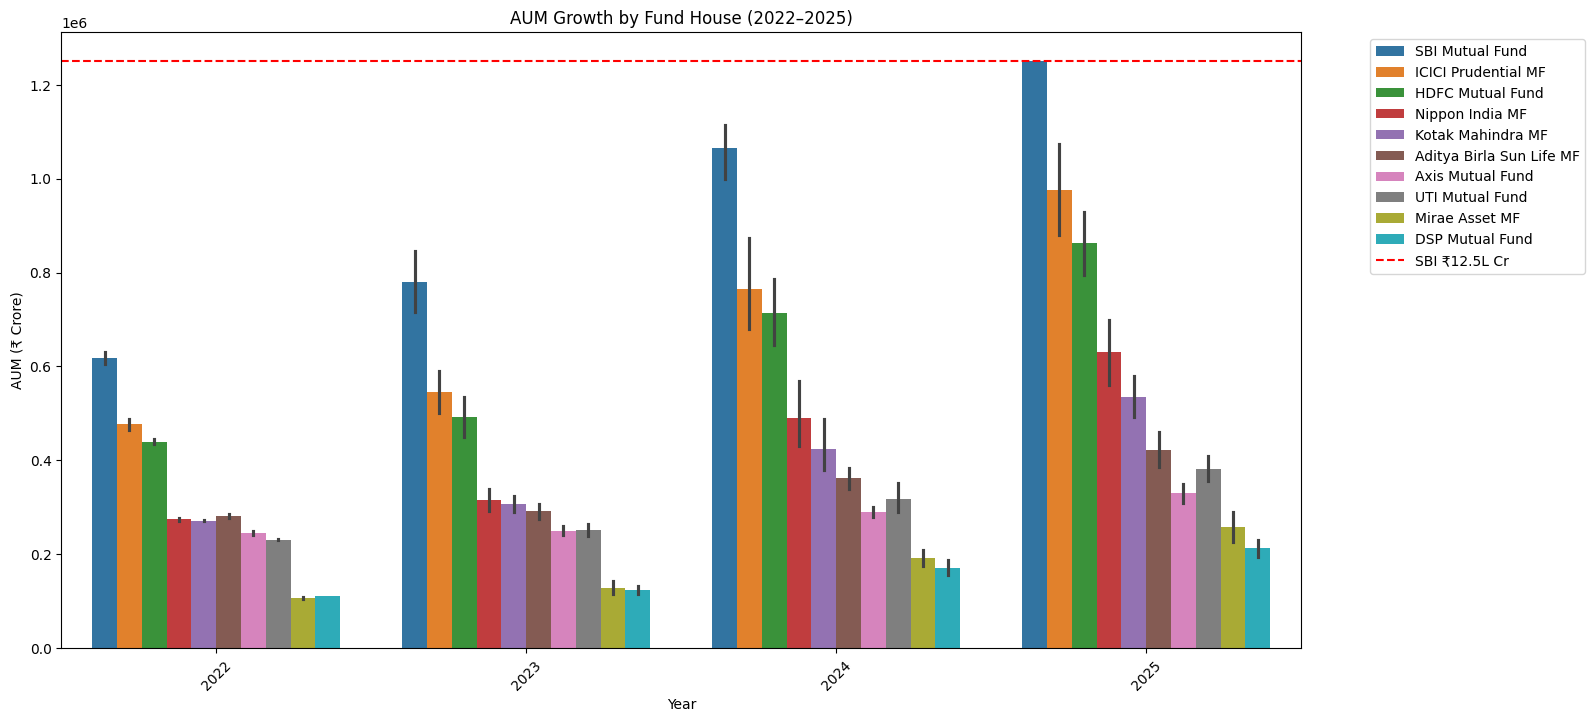

In [61]:
# -----------------------------------
# Convert Date Column
# -----------------------------------

aum_by_fund_house['date'] = pd.to_datetime(
    aum_by_fund_house['date'],
    errors='coerce'
)

# -----------------------------------
# Extract Year
# -----------------------------------

aum_by_fund_house['year'] = (
    aum_by_fund_house['date'].dt.year
)

# -----------------------------------
# Plot AUM Growth Chart
# -----------------------------------

plt.figure(figsize=(16,8))

sns.barplot(
    data=aum_by_fund_house,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

# -----------------------------------
# Highlight SBI Dominance
# -----------------------------------

plt.axhline(
    y=1250000,
    color='red',
    linestyle='--',
    label='SBI ₹12.5L Cr'
)

# -----------------------------------
# Chart Labels
# -----------------------------------

plt.title("AUM Growth by Fund House (2022–2025)")

plt.xlabel("Year")

plt.ylabel("AUM (₹ Crore)")

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

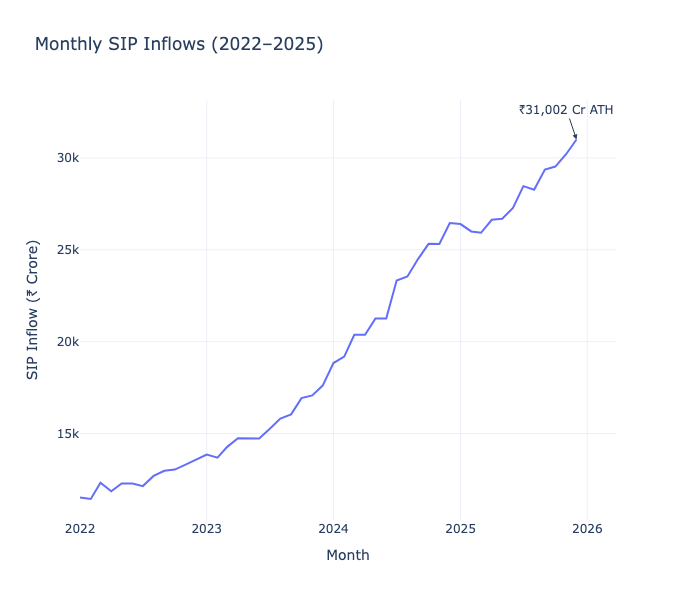

In [62]:
# -----------------------------------
# Create SIP DataFrame
# -----------------------------------

sip = loaded_data['monthly_sip_inflows']

# -----------------------------------
# Convert Month Column
# -----------------------------------

sip['month'] = pd.to_datetime(
    sip['month'],
    errors='coerce'
)

# -----------------------------------
# Plot SIP Trend
# -----------------------------------

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (2022–2025)'
)

# -----------------------------------
# Add Annotation for All-Time High
# -----------------------------------

fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr ATH',
    showarrow=True,
    arrowhead=2
)

# -----------------------------------
# Layout Improvements
# -----------------------------------

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    template='plotly_white',
    height=600
)

# -----------------------------------
# Show Chart
# -----------------------------------

fig.show()

Index(['month', 'category', 'net_inflow_crore', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')
     month         category  net_inflow_crore  Unnamed: 3  Unnamed: 4  \
0  2024-04        Large Cap              2413         NaN         NaN   
1  2024-04          Mid Cap              3897         NaN         NaN   
2  2024-04        Small Cap              3533         NaN         NaN   
3  2024-04        Flexi Cap              4947         NaN         NaN   
4  2024-04  Large & Mid Cap              4214         NaN         NaN   

   Unnamed: 5  Unnamed: 6  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  


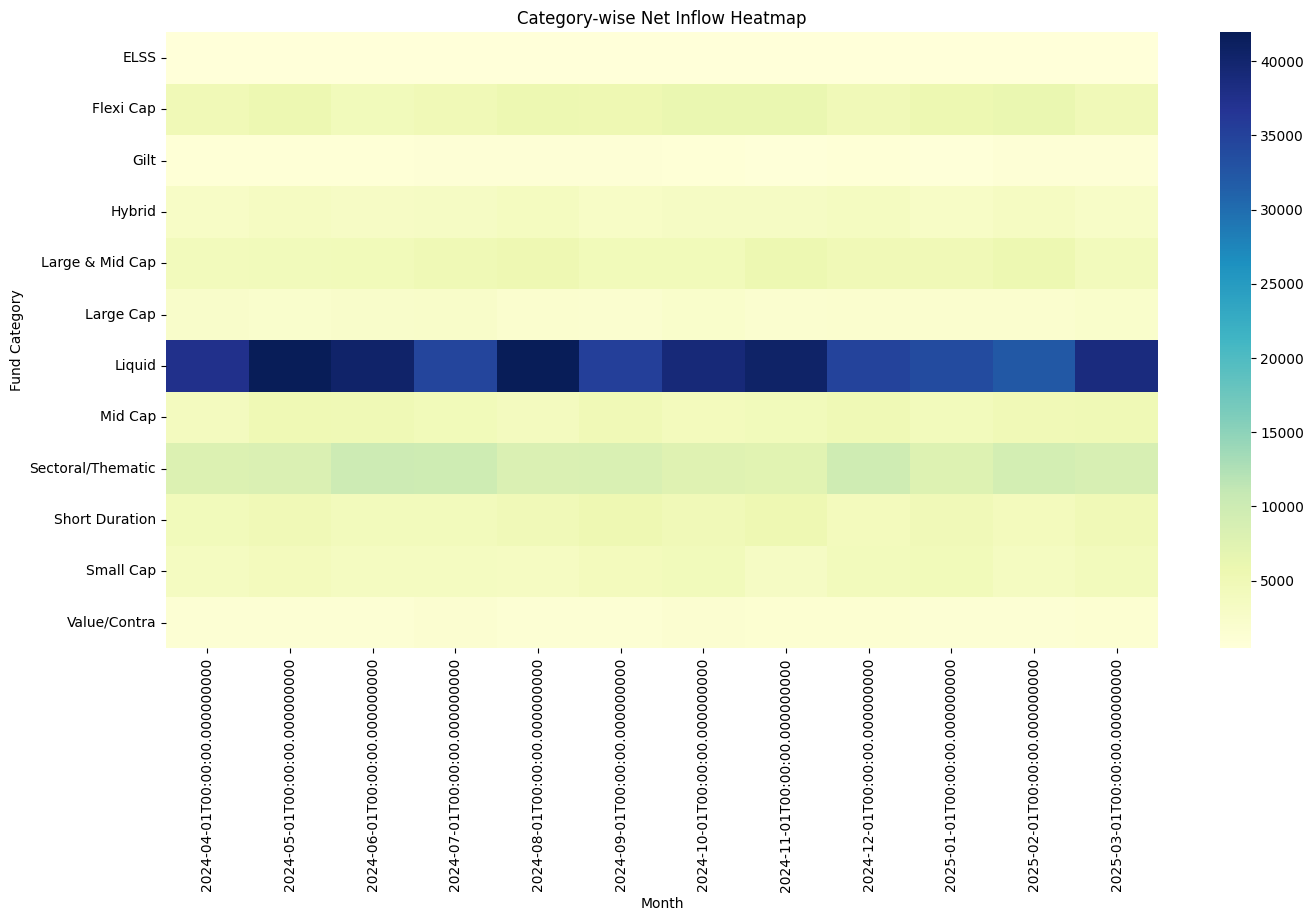

In [63]:
# -----------------------------------
# Create Category DataFrame
# -----------------------------------

category = loaded_data['category_inflows']

# -----------------------------------
# Check Columns
# -----------------------------------

print(category.columns)

print(category.head())

# -----------------------------------
# Convert Month Column
# -----------------------------------

category['month'] = pd.to_datetime(
    category['month'],
    errors='coerce'
)

# -----------------------------------
# Create Pivot Table
# -----------------------------------

pivot_df = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

# -----------------------------------
# Plot Heatmap
# -----------------------------------

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot_df,
    cmap='YlGnBu'
)

# -----------------------------------
# Chart Title
# -----------------------------------

plt.title("Category-wise Net Inflow Heatmap")

plt.xlabel("Month")

plt.ylabel("Fund Category")

plt.show()

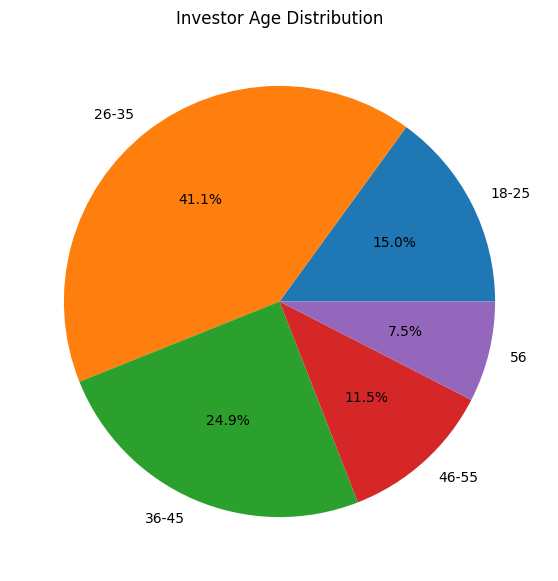

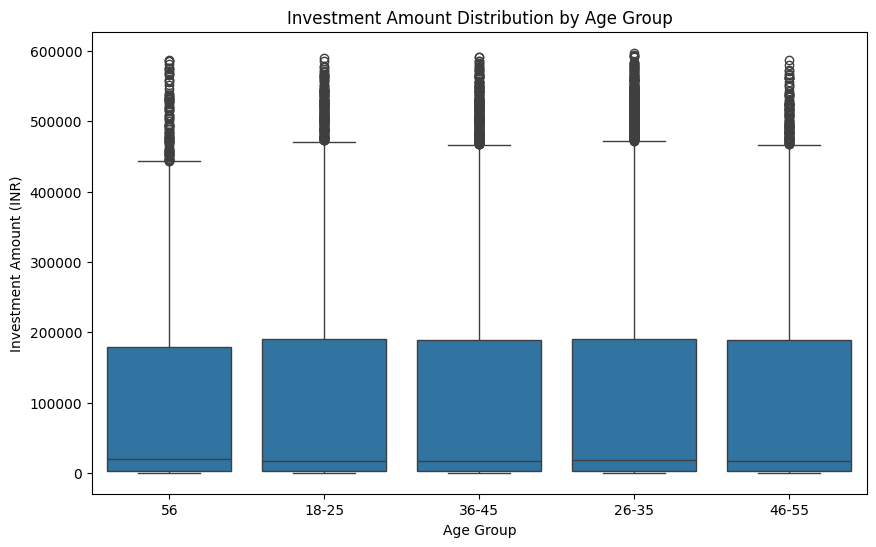

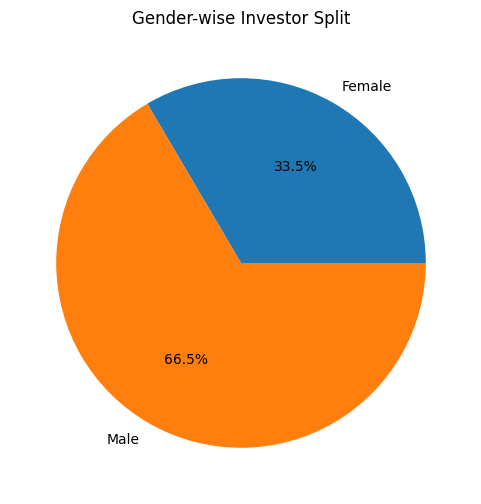

In [64]:
investor = loaded_data['investor_transactions']

age_data = investor.groupby(
    'age_group'
)['amount_inr'].count()

plt.figure(figsize=(7,7))

plt.pie(
    age_data,
    labels=age_data.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Distribution")

plt.show()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (INR)")

plt.show()

gender_data = investor.groupby(
    'gender'
)['amount_inr'].count()

plt.figure(figsize=(6,6))

plt.pie(
    gender_data,
    labels=gender_data.index,
    autopct='%1.1f%%'
)

plt.title("Gender-wise Investor Split")

plt.show()

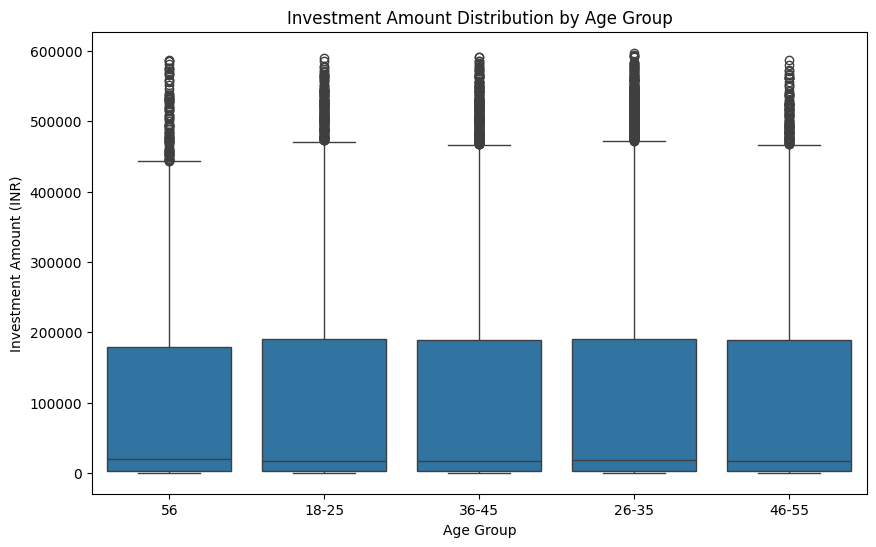

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (INR)")

plt.show()

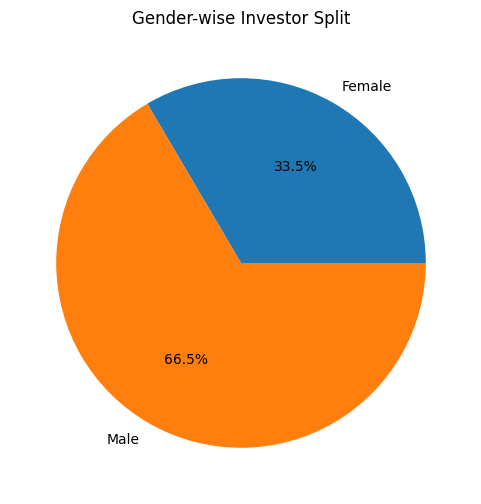

In [66]:
gender_data = investor.groupby(
    'gender'
)['amount_inr'].count()

plt.figure(figsize=(6,6))

plt.pie(
    gender_data,
    labels=gender_data.index,
    autopct='%1.1f%%'
)

plt.title("Gender-wise Investor Split")

plt.show()

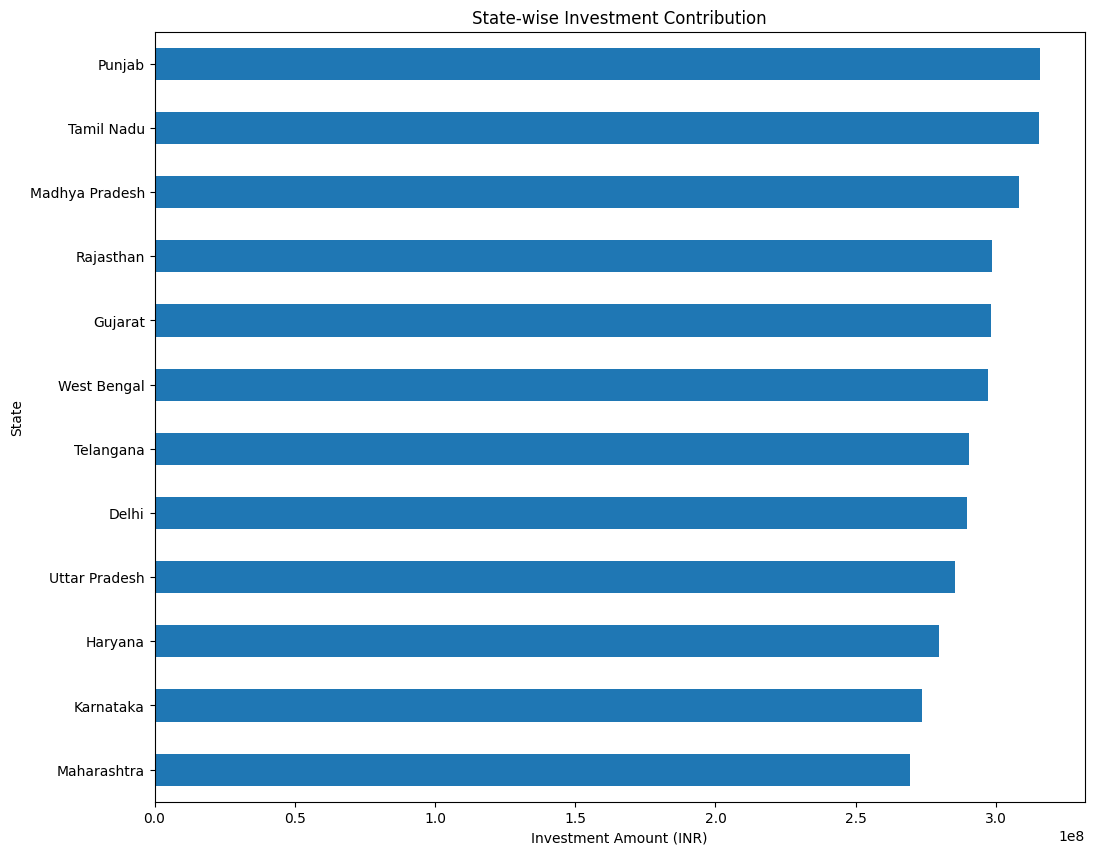

In [67]:
geo = loaded_data['investor_transactions']

state_data = geo.groupby(
    'state'
)['amount_inr'].sum()

state_data = state_data.sort_values()

plt.figure(figsize=(12,10))

state_data.plot(kind='barh')

plt.title("State-wise Investment Contribution")

plt.xlabel("Investment Amount (INR)")

plt.ylabel("State")

plt.show()

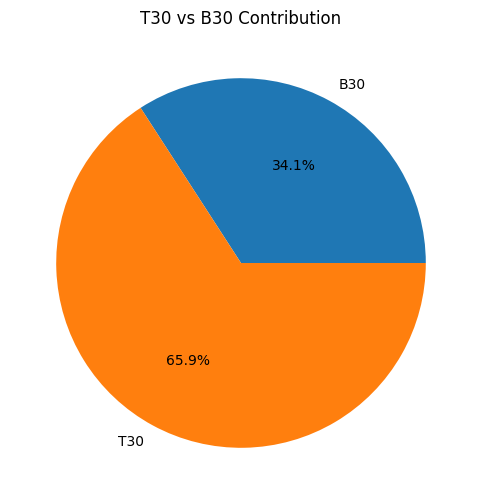

In [68]:
tier_data = geo.groupby(
    'city_tier'
)['amount_inr'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Contribution")

plt.show()

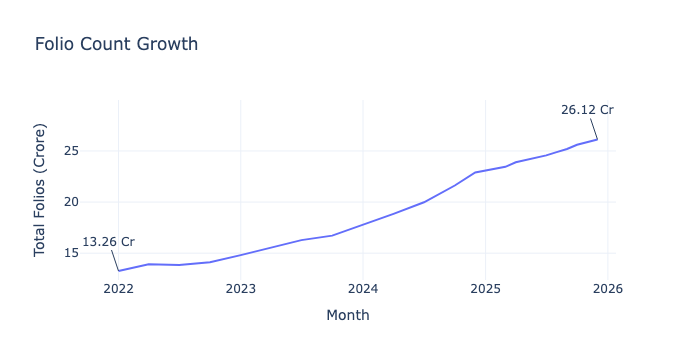

In [69]:
folio = loaded_data['industry_folio_count']

folio['month'] = pd.to_datetime(
    folio['month'],
    errors='coerce'
)

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Folio Count Growth'
)

fig.add_annotation(
    x='2022-01-01',
    y=13.26,
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x='2025-12-01',
    y=26.12,
    text='26.12 Cr',
    showarrow=True
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)',
    template='plotly_white'
)

fig.show()

In [70]:
pivot_nav = final_nav_df.pivot_table(
    index='date',
    columns='scheme_name',
    values='nav'
)

daily_returns = pivot_nav.pct_change()

corr_matrix = daily_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("NAV Return Correlation Matrix")

plt.show()

TypeError: agg function failed [how->mean,dtype->object]

/var/folders/m1/gtbjxf0565l784fw0cc612mc0000gn/T/ipykernel_1878/631023120.py:19: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



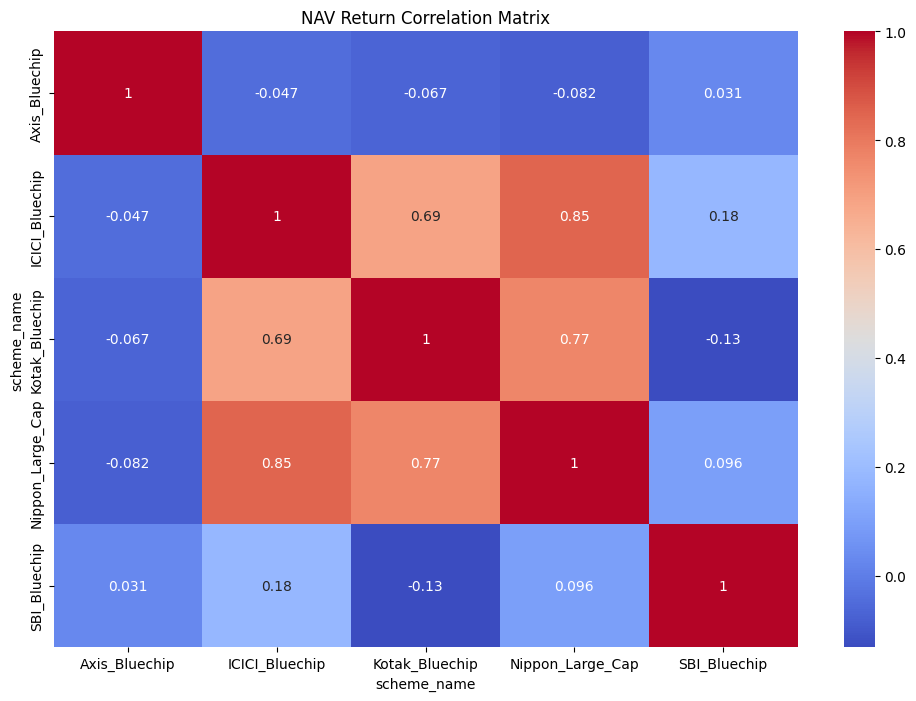

In [72]:
final_nav_df['nav'] = pd.to_numeric(
    final_nav_df['nav'],
    errors='coerce'
)

final_nav_df['date'] = pd.to_datetime(
    final_nav_df['date'],
    errors='coerce'
)

final_nav_df.dropna(inplace=True)

pivot_nav = final_nav_df.pivot_table(
    index='date',
    columns='scheme_name',
    values='nav'
)

daily_returns = pivot_nav.pct_change()

corr_matrix = daily_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("NAV Return Correlation Matrix")

plt.show()

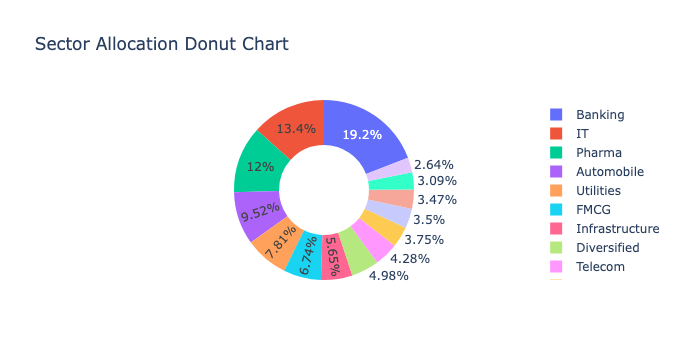

In [71]:
import plotly.graph_objects as go
sector_weights = portfolio.groupby(
    'sector'
)['weight_pct'].sum()

fig = go.Figure(
    data=[go.Pie(
        labels=sector_weights.index,
        values=sector_weights.values,
        hole=0.5
    )]
)

fig.update_layout(
    title='Sector Allocation Donut Chart'
)

fig.show()

### Finding 1
Large-cap schemes experienced strong NAV appreciation during the 2023 bull market.